In [83]:
import os
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, START, END


In [84]:
load_dotenv()

True

In [85]:
class AgentState(TypedDict):
    raw_notes: str
    meeting_type: str
    extraction_prompt: str
    response: str

In [86]:
class MeetingType(BaseModel):
    meeting_type: Literal['Standup', 'Client', 'Stratergy'] = Field(description="Based on the raw notes, llm returns the type of meeting; Either Standup, Client, Stratergy")

In [87]:
llm = ChatOpenAI(api_key=os.getenv('OPENAI_API_KEY'), model='gpt-5-mini', temperature=0)
llm_meeting_type = llm.with_structured_output(MeetingType)

In [88]:
def define_meeting_type(state):
    raw_notes = state['raw_notes']
    meeting_type = llm_meeting_type.invoke(f"Here are your raw notes of the meeting {raw_notes}, return the type of meeting.").meeting_type

    return {'meeting_type': meeting_type}


In [89]:
def standup(state):
    raw_notes = state['raw_notes']
    extraction_prompt = f"""
        You are an expert at analyzing standup meeting notes.
        Extract and structure the following from the raw notes:

        ## Daily Standup Report

        ### Tasks
        - List each person and what they are working on today

        ### Blockers
        - List anything that is blocking progress
        - If none mentioned, write: No blockers reported

        ### At Risk
        - List any sprint goals or deadlines that are at risk
        - If none mentioned, write: Nothing at risk

        Raw notes:
        {raw_notes}

        Be concise. Use bullet points. Do not add anything not mentioned in the notes.
        """
    return {'extraction_prompt': extraction_prompt}


In [90]:
def client(state):
    raw_notes = state['raw_notes']
    extraction_prompt = f"""
        You are an expert at analyzing client call notes.
        Extract and structure the following from the raw notes:

        ## Client Call Report

        ###Client Name
        - Name of the Client
        
        ### Commitments Made
        - List every commitment or promise made to the client with deadlines if mentioned

        ### Follow-ups
        - List follow-up actions with the owner's name if mentioned

        ### Opportunities
        - List any budget signals, upsell opportunities, or positive indicators
        - If none mentioned, write: None identified

        ### Client Sentiment
        - One sentence describing how the client came across

        Raw notes:
        {raw_notes}

        Be concise. Use bullet points. Do not add anything not mentioned in the notes.
        """
    return {'extraction_prompt': extraction_prompt}

In [91]:
def stratergy(state):
    raw_notes = state['raw_notes']
    extraction_prompt = f"""
        You are an expert at analyzing strategy meeting notes.
        Extract and structure the following from the raw notes:

        ## Strategy Session Report

        ### Decisions Made
        - List every decision that was finalised in this meeting

        ### Open Questions
        - List anything still being debated or unresolved
        - If none mentioned, write: None

        ### Next Steps
        - List concrete next steps with owners and deadlines if mentioned

        ### Risks & Dependencies
        - List anything flagged as a risk or a blocker to execution
        - If none mentioned, write: None identified

        Raw notes:
        {raw_notes}

        Be concise. Use bullet points. Do not add anything not mentioned in the notes.
        """
    return {'extraction_prompt': extraction_prompt}

In [92]:
def router(state):
    return state['meeting_type'].lower()

In [93]:
def generate_report(state):
    extraction_prompt = state['extraction_prompt']
    report = llm.invoke(f"You are a meeting notes generator. Generate a report for that can be sent to the team over slack. {extraction_prompt}")

    return {'response': report.content}

In [94]:
notes_processor_graph = StateGraph(AgentState)
notes_processor_graph.add_node('meeting type', define_meeting_type)
notes_processor_graph.add_node('standup', standup)
notes_processor_graph.add_node('client', client)
notes_processor_graph.add_node('stratergy', stratergy)
notes_processor_graph.add_node('generate report', generate_report)

In [95]:
notes_processor_graph.add_edge(START, 'meeting type')
notes_processor_graph.add_conditional_edges(
    'meeting type',
    router,
    {
        'standup':'standup',
        'client': 'client',
        'stratergy': 'stratergy'
    }
)
notes_processor_graph.add_edge('standup', 'generate report')
notes_processor_graph.add_edge('client', 'generate report')
notes_processor_graph.add_edge('stratergy', 'generate report')
notes_processor_graph.add_edge('generate report', END)


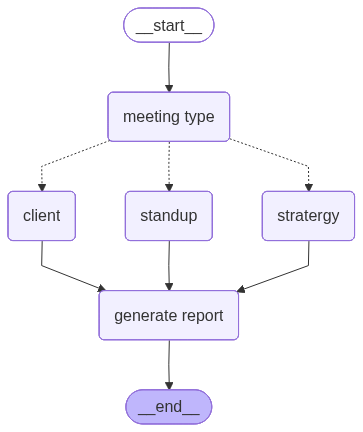

In [96]:
notes_processor_graph_compiled = notes_processor_graph.compile()
notes_processor_graph_compiled

In [98]:
result = notes_processor_graph_compiled.invoke(
    {
        'raw_notes': """
        discussed expanding into the middle east market
decided we will go enterprise tier first before any smb push
the question of whether to hire a regional sales head or use a partner is still open
marketing said they need 3 more months before any launch
legal review is mandatory before we can even talk to customers there
next step is a competitive analysis, priya owns this, needs to be done by end of month
data residency laws in uae are a concern, need to flag to engineering
budget for this hasnt been approved yet, finance meeting next week
        """
    }
)
print(result['response'])

## Strategy Session Report

### Decisions Made
- Go enterprise tier first before any smb push

### Open Questions
- Whether to hire a regional sales head or use a partner is still open
- Budget for this has not been approved yet (finance meeting next week)
- Legal review status (mandatory before customer engagement) — implied unresolved
- Launch timing given marketing needs 3 more months

### Next Steps
- Competitive analysis — Priya owns this; needs to be done by end of month
- Flag data residency laws in UAE to engineering (owner not specified)
- Complete legal review before talking to customers in the region (owner not specified)
- Finance meeting next week to address budget approval (owner not specified)

### Risks & Dependencies
- Data residency laws in UAE are a concern
- Legal review is mandatory before any customer engagement (blocks outreach)
- Marketing requires 3 more months before any launch
- Budget has not been approved yet (pending finance meeting)
